In [40]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn import metrics
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier
import pydot
from sklearn.tree import export_graphviz
from io import StringIO
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.svm import SVC
import seaborn as sns

In [41]:
from sklearn.cluster import KMeans, MeanShift,estimate_bandwidth,DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage , fcluster
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif

In [42]:
data=pd.read_csv(r'D:\jupyter\wine_data.csv')
data

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,11.6,0.580,0.66,2.20,0.074,10.0,47.0,1.00080,3.25,0.57,9.0,3
1,10.4,0.610,0.49,2.10,0.200,5.0,16.0,0.99940,3.16,0.63,8.4,3
2,7.4,1.185,0.00,4.25,0.097,5.0,14.0,0.99660,3.63,0.54,10.7,3
3,10.4,0.440,0.42,1.50,0.145,34.0,48.0,0.99832,3.38,0.86,9.9,3
4,8.3,1.020,0.02,3.40,0.084,6.0,11.0,0.99892,3.48,0.49,11.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...
20995,9.7,1.020,0.91,50.00,0.412,114.6,181.7,1.02085,3.30,0.89,12.0,9
20996,10.2,0.610,0.88,53.80,0.250,62.4,204.7,1.02776,3.52,1.14,9.7,9
20997,13.4,0.460,1.04,52.10,0.449,63.0,273.5,1.02618,2.89,1.76,9.3,9
20998,6.6,1.030,1.09,25.30,0.138,179.8,295.0,1.02476,2.94,1.54,12.9,9


In [43]:
def transform(x):
    if x<=4:
        return 0
    elif x<=7:
        return 1
    else:
        return 2
data['quality']=data['quality'].apply(transform)
data

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,11.6,0.580,0.66,2.20,0.074,10.0,47.0,1.00080,3.25,0.57,9.0,0
1,10.4,0.610,0.49,2.10,0.200,5.0,16.0,0.99940,3.16,0.63,8.4,0
2,7.4,1.185,0.00,4.25,0.097,5.0,14.0,0.99660,3.63,0.54,10.7,0
3,10.4,0.440,0.42,1.50,0.145,34.0,48.0,0.99832,3.38,0.86,9.9,0
4,8.3,1.020,0.02,3.40,0.084,6.0,11.0,0.99892,3.48,0.49,11.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
20995,9.7,1.020,0.91,50.00,0.412,114.6,181.7,1.02085,3.30,0.89,12.0,2
20996,10.2,0.610,0.88,53.80,0.250,62.4,204.7,1.02776,3.52,1.14,9.7,2
20997,13.4,0.460,1.04,52.10,0.449,63.0,273.5,1.02618,2.89,1.76,9.3,2
20998,6.6,1.030,1.09,25.30,0.138,179.8,295.0,1.02476,2.94,1.54,12.9,2


In [5]:
data.dtypes

fixed_acidity           float64
volatile_acidity        float64
citric_acid             float64
residual_sugar          float64
chlorides               float64
free_sulfur_dioxide     float64
total_sulfur_dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

In [6]:
data.shape

(21000, 12)

In [7]:
# knn

In [8]:
x=data.iloc[:,:-1]
y=data.iloc[:,-1]
scale=StandardScaler()
x=scale.fit_transform(x)

In [9]:
xtrain , xtest , ytrain , ytest=train_test_split(x,y , test_size=0.3, random_state=42)

In [10]:
knn=KNeighborsClassifier()
knn.fit(xtrain, ytrain)
ypred=knn.predict(xtest)

In [11]:
knn.get_params()

{'algorithm': 'auto',
 'leaf_size': 30,
 'metric': 'minkowski',
 'metric_params': None,
 'n_jobs': None,
 'n_neighbors': 5,
 'p': 2,
 'weights': 'uniform'}

In [12]:
acc=metrics.accuracy_score(ytest,ypred)
acc

0.6222222222222222

In [13]:
p_grid={'n_neighbors':np.arange(1,10),'weights':['uniform','distance'], 'algorithm':['auto','ball_tree','kd_tree','brute']}
knn=KNeighborsClassifier()
knn_cv=GridSearchCV(knn,p_grid, cv=10 ,n_jobs=-1)
knn_cv.fit(x,y)
print(knn_cv.best_params_)
print(knn_cv.best_score_)

{'algorithm': 'auto', 'n_neighbors': 8, 'weights': 'distance'}
0.7345714285714287


In [65]:
knn=KNeighborsClassifier(algorithm= 'auto', n_neighbors= 8, weights= 'distance')
knn.fit(xtrain , ytrain)
ypred_knn=knn.predict(xtest)

In [15]:
knn_score_test=knn.score(xtest,ytest)
knn_score_test

0.7431746031746032

In [16]:
knn_score_train=knn.score(xtrain,ytrain)
knn_score_train

1.0

In [17]:
acc_knn=metrics.accuracy_score(ytest,ypred_knn)
acc_knn

0.7431746031746032

In [18]:
classification_report(ytest,ypred_knn)

'              precision    recall  f1-score   support\n\n           0       0.67      0.69      0.68      1783\n           1       0.87      0.80      0.83      2740\n           2       0.65      0.71      0.68      1777\n\n    accuracy                           0.74      6300\n   macro avg       0.73      0.73      0.73      6300\nweighted avg       0.75      0.74      0.75      6300\n'

In [19]:
newdata={'fixed_acidity':[11.6], 'volatile_acidity':[0.580], 'citric_acid':[0.66], 'residual_sugar':[2.20],'chlorides':[0.074], 'free_sulfur_dioxide':[10.0], 'total_sulfur_dioxide':[47.0], 'density':[1.00080],'pH':[3.25], 'sulphates':[0.57], 'alcohol':[9.0]}
neaw_data=pd.DataFrame(newdata)
scale=StandardScaler()
neaw_data=scale.fit_transform(neaw_data)
predict=knn.predict(neaw_data)
print(f'predicted quality:{predict}')  #True prediction

predicted quality:[0]


In [20]:
#decision tree 1

In [9]:
x=data.iloc[:,:-1]
y=data.iloc[:,-1]
scale=StandardScaler()
x=scale.fit_transform(x)

In [10]:
xtrain , xtest , ytrain , ytest=train_test_split(x,y , test_size=0.3, random_state=42)

In [11]:
p_grid={'criterion': ['gini', 'entropy'], 'max_depth': [3,4,5],'min_samples_split': [ 5, 10],'min_samples_leaf': [1, 2, 3],'max_features': [None, 'sqrt', 'log2']}
dtree=DecisionTreeClassifier()
tree_cv=GridSearchCV(estimator=dtree,param_grid=p_grid,cv=5, n_jobs=-1,verbose=2)
tree_cv.fit(x, y)
print(tree_cv.best_params_)
print(tree_cv.best_score_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
{'criterion': 'entropy', 'max_depth': 5, 'max_features': 'log2', 'min_samples_leaf': 3, 'min_samples_split': 5}
0.5698571428571428


In [12]:
dtree=DecisionTreeClassifier(criterion='entropy',max_depth=5,max_features='log2',min_samples_leaf=3, min_samples_split=5,class_weight='balanced')
dtree.fit(x,y)

DecisionTreeClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=5, max_features='log2', min_samples_leaf=3,
                       min_samples_split=5)

In [13]:
data.columns

Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

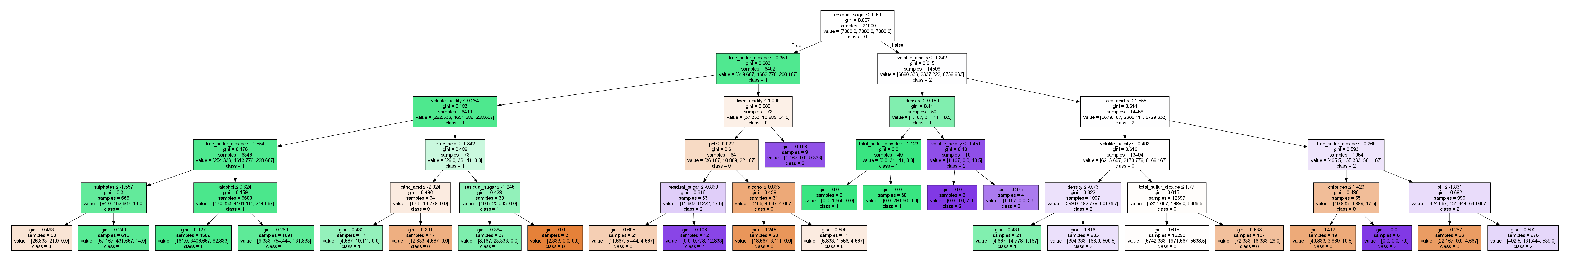

In [26]:
featureNames=['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar','chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density','pH', 'sulphates', 'alcohol']
dot_data=StringIO()
out=export_graphviz(dtree,feature_names=featureNames,out_file=dot_data,class_names=np.unique(ytrain).astype(str),filled=True,special_characters=True,rotate=False)
graph=pydot.graph_from_dot_data(dot_data.getvalue())
dataa='dtree.png'
graph[0].write_png(dataa)
img=mpimg.imread(dataa)
plt.figure(figsize=(20,40))
plt.imshow(img,interpolation='nearest')
plt.axis('off')
plt.show()

In [27]:
ypred_dt=dtree.predict(xtest)
acc_dtree=metrics.accuracy_score(ytest,ypred_dt)
acc_dtree

0.573968253968254

In [28]:
tree_score_test=dtree.score(xtest,ytest)
tree_score_test

0.573968253968254

In [29]:
tree_score_train=dtree.score(xtrain,ytrain)
tree_score_train

0.5728571428571428

In [30]:
classification_report(ytest,ypred_dt)

'              precision    recall  f1-score   support\n\n           0       0.41      0.86      0.55      1783\n           1       0.93      0.66      0.77      2740\n           2       0.46      0.16      0.24      1777\n\n    accuracy                           0.57      6300\n   macro avg       0.60      0.56      0.52      6300\nweighted avg       0.65      0.57      0.56      6300\n'

In [14]:
newdata={'fixed_acidity':[11.6], 'volatile_acidity':[0.580], 'citric_acid':[0.66], 'residual_sugar':[2.20],'chlorides':[0.074], 'free_sulfur_dioxide':[10.0], 'total_sulfur_dioxide':[47.0], 'density':[1.00080],'pH':[3.25], 'sulphates':[0.57], 'alcohol':[9.0]}
neaw_data=pd.DataFrame(newdata)
scale=StandardScaler()
neaw_data=scale.fit_transform(neaw_data)
predict=dtree.predict(neaw_data)
print(f'predicted quality:{predict}') #wrong prediction

predicted quality:[2]


In [15]:
#decision tree 2

In [16]:
selector=SelectKBest(score_func=f_classif,k=5)
xtrain=selector.fit_transform(xtrain, ytrain)
feature_names=['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol']
selected_features=selector.get_support(indices=True)
selected_features_name=[feature_names[i] for i in selected_features]
print(selected_features_name)


['volatile_acidity', 'citric_acid', 'residual_sugar', 'free_sulfur_dioxide', 'density']


In [17]:
x=data[['volatile_acidity', 'citric_acid', 'residual_sugar', 'free_sulfur_dioxide', 'density']]
y=data.iloc[:,-1]
scale=StandardScaler()
x=scale.fit_transform(x)

In [18]:
xtrain , xtest , ytrain , ytest=train_test_split(x,y , test_size=0.3, random_state=42)

In [19]:
p_grid={'criterion': ['gini', 'entropy'], 'max_depth': [3,4,5],'min_samples_split': [ 5, 10],'min_samples_leaf': [1, 2, 3],'max_features': [None, 'sqrt', 'log2']}
dtree=DecisionTreeClassifier()
dtree_cv=GridSearchCV(estimator=dtree,param_grid=p_grid,cv=5, n_jobs=-1,verbose=2)
dtree_cv.fit(x, y)
print(dtree_cv.best_params_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
{'criterion': 'gini', 'max_depth': 5, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5}


In [68]:
dtree=DecisionTreeClassifier(criterion='gini',max_depth=5,max_features='log2',min_samples_leaf=1,min_samples_split=5,class_weight='balanced')
dtree.fit(xtrain,ytrain)
ypred_dtree=dtree.predict(xtest)

In [21]:
newdata={ 'volatile_acidity':[0.580], 'citric_acid':[0.66], 'residual_sugar':[2.20],'free_sulfur_dioxide':[10.0],
         'density':[1.00080]}
newdata_df=pd.DataFrame(newdata)
scale=StandardScaler()
neaw_data=scale.fit_transform(newdata_df)
predict=dtree.predict(newdata_df)  
print(f'predicted quality:{predict}') #True prediction

predicted quality:[0]


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


In [69]:
ypred_dt=dtree.predict(xtest)

In [5]:
#svm

In [44]:
x=data.iloc[:,:-1]
y=data.iloc[:,-1]
scale=StandardScaler()
x=scale.fit_transform(x)

In [45]:
xtrain , xtest , ytrain , ytest=train_test_split(x,y , test_size=0.3, random_state=42)

In [46]:
p_grid={'kernel':['linear','poly','rbf','sigmoid'],'C':[0.1,1,10],'gamma':['scale','auto']}
svm=SVC()
svm_cv=GridSearchCV(estimator=svm,param_grid=p_grid,cv=5,n_jobs=-1,verbose=2)
svm_cv.fit(x,y)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'poly', 'rbf', 'sigmoid']},
             verbose=2)

In [47]:
print(svm_cv.best_params_)
print(svm_cv.best_score_)

{'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
0.5843333333333334


In [48]:
svm=SVC(C= 10, gamma='auto', kernel='rbf')
svm.fit(xtrain,ytrain)
ypred_svm=svm.predict(xtest)
acc_svm=metrics.accuracy_score(ytest,ypred_svm)
acc_svm

0.5904761904761905

In [49]:
svm_score_test=svm.score(xtest,ytest)
svm_score_test

0.5904761904761905

In [50]:
svm_score_train=svm.score(xtrain,ytrain)
svm_score_train

0.6636054421768708

In [51]:
classification_report(ytest,ypred_svm)

'              precision    recall  f1-score   support\n\n           0       0.45      0.48      0.46      1783\n           1       0.91      0.68      0.78      2740\n           2       0.43      0.57      0.49      1777\n\n    accuracy                           0.59      6300\n   macro avg       0.60      0.58      0.58      6300\nweighted avg       0.64      0.59      0.61      6300\n'

In [52]:
newdata={'fixed_acidity':[11.6], 'volatile_acidity':[0.580], 'citric_acid':[0.66], 'residual_sugar':[2.20],'chlorides':[0.074], 'free_sulfur_dioxide':[10.0], 'total_sulfur_dioxide':[47.0], 'density':[1.00080],'pH':[3.25], 'sulphates':[0.57], 'alcohol':[9.0]}
neaw_data=pd.DataFrame(newdata)
scale=StandardScaler()
neaw_data=scale.fit_transform(neaw_data)
predict=svm.predict(neaw_data)
print(f'predicted quality:{predict}') #wrong prediction

predicted quality:[2]


In [53]:
cor=data.corr()
print(cor['quality']) # corridation payin ast pas model khati nist pas nabayad as in algorithem estefade kard(dalil wrong prediction)

fixed_acidity           0.003199
volatile_acidity       -0.010846
citric_acid             0.007702
residual_sugar          0.005407
chlorides               0.017535
free_sulfur_dioxide     0.008496
total_sulfur_dioxide    0.000851
density                -0.001621
pH                      0.006962
sulphates               0.003717
alcohol                 0.007953
quality                 1.000000
Name: quality, dtype: float64


In [ ]:
#LogisticRegression

In [54]:
x=data.iloc[:,:-1]
y=data.iloc[:,-1]
scale=StandardScaler()
x=scale.fit_transform(x)

In [55]:
xtrain , xtest , ytrain , ytest=train_test_split(x,y , test_size=0.3, random_state=42)

In [56]:
p_grid={'penalty':['l1','l2'],'C':[0.01,0.1,1],'solver':['liblinear','saga'],'max_iter':[100,300]}
lr=LogisticRegression()
lr_cv=GridSearchCV(estimator=lr,param_grid=p_grid,cv=5,n_jobs=-1,verbose=2)
lr_cv.fit(x,y)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5, estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1], 'max_iter': [100, 300],
                         'penalty': ['l1', 'l2'],
                         'solver': ['liblinear', 'saga']},
             verbose=2)

In [57]:
print(lr_cv.best_params_)
print(lr_cv.best_score_)

{'C': 0.1, 'max_iter': 300, 'penalty': 'l1', 'solver': 'saga'}
0.5478095238095239


In [58]:
lr=LogisticRegression(C= 0.1, max_iter= 300, penalty= 'l1', solver='saga')
lr.fit(xtrain,ytrain)
ypred_lr=lr.predict(xtest)
acc_lr=metrics.accuracy_score(ytest,ypred_lr)
acc_lr

0.5550793650793651

In [59]:
lr_score_test=lr.score(xtest,ytest)
lr_score_test

0.5550793650793651

In [60]:
lr_score_train=lr.score(xtrain,ytrain)
lr_score_train

0.5672789115646258

In [61]:
classification_report(ytest,ypred_lr)

'              precision    recall  f1-score   support\n\n           0       0.40      0.42      0.41      1783\n           1       0.85      0.68      0.76      2740\n           2       0.40      0.50      0.44      1777\n\n    accuracy                           0.56      6300\n   macro avg       0.55      0.53      0.54      6300\nweighted avg       0.60      0.56      0.57      6300\n'

In [62]:
newdata={'fixed_acidity':[11.6], 'volatile_acidity':[0.580], 'citric_acid':[0.66], 'residual_sugar':[2.20],'chlorides':[0.074], 'free_sulfur_dioxide':[10.0], 'total_sulfur_dioxide':[47.0], 'density':[1.00080],'pH':[3.25], 'sulphates':[0.57], 'alcohol':[9.0]}
neaw_data=pd.DataFrame(newdata)
scale=StandardScaler()
neaw_data=scale.fit_transform(neaw_data)
predict=lr.predict(neaw_data)
print(f'predicted quality:{predict}')  #wrong prediction

predicted quality:[1]


In [63]:
cor=data.corr()
print(cor['quality']) # corridation payon ast pas model khati nist pas nabayad as in algorithem estefade kard(dalil wrong predict)

fixed_acidity           0.003199
volatile_acidity       -0.010846
citric_acid             0.007702
residual_sugar          0.005407
chlorides               0.017535
free_sulfur_dioxide     0.008496
total_sulfur_dioxide    0.000851
density                -0.001621
pH                      0.006962
sulphates               0.003717
alcohol                 0.007953
quality                 1.000000
Name: quality, dtype: float64


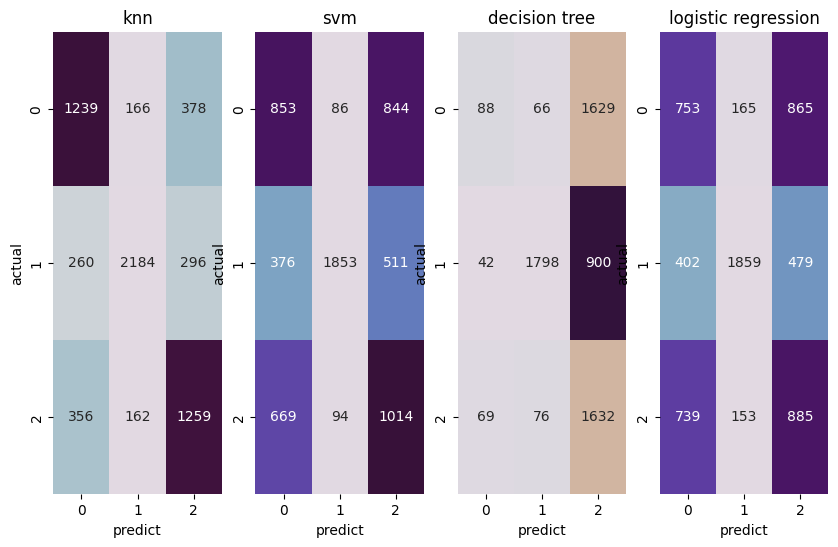

In [70]:
cm_knn=confusion_matrix(ytest,ypred_knn)
cm_svm=confusion_matrix(ytest,ypred_svm)
cm_dt=confusion_matrix(ytest,ypred_dt)
cm_lr=confusion_matrix(ytest,ypred_lr)
fig, axes = plt.subplots(1,4,figsize=(10,6))
sns.heatmap(cm_knn,annot=True,fmt='d',cmap='twilight',ax=axes[0],cbar=False)
axes[0].set_title('knn')
axes[0].set_xlabel('predict')
axes[0].set_ylabel('actual')

sns.heatmap(cm_svm,annot=True,fmt='d',cmap='twilight',ax=axes[1],cbar=False)
axes[1].set_title('svm')
axes[1].set_xlabel('predict')
axes[1].set_ylabel('actual')

sns.heatmap(cm_dt,annot=True,fmt='d',cmap='twilight',ax=axes[2],cbar=False)
axes[2].set_title('decision tree')
axes[2].set_xlabel('predict')
axes[2].set_ylabel('actual')

sns.heatmap(cm_lr,annot=True,fmt='d',cmap='twilight',ax=axes[3],cbar=False)
axes[3].set_title('logistic regression')
axes[3].set_xlabel('predict')
axes[3].set_ylabel('actual')


plt.show()

In [ ]:
#KMeans

In [5]:
data=pd.read_csv(r'D:\jupyter\wine_data.csv')

In [7]:
x=data.iloc[:,:-1]
scale=StandardScaler()
x=scale.fit_transform(x)

In [8]:
y=[]
for k in np.arange(1,10):
    kmn=KMeans(n_clusters=k)
    kmn.fit(x)
    y.append(kmn.inertia_)
y

[230999.99999999988,
 100969.9886040366,
 90790.97072431148,
 84494.2175020192,
 79284.21055296953,
 76475.6279677677,
 74039.08807314359,
 72103.38318269416,
 74663.84088315605]

Text(0, 0.5, 'inertia')

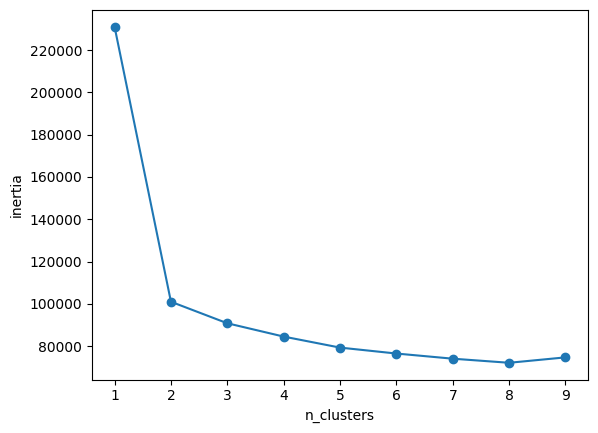

In [9]:
plt.plot(np.arange(1,10),y,'o-')
plt.xlabel('n_clusters')
plt.ylabel('inertia')

In [14]:
kmn=KMeans(init='k-means++',n_clusters=2,n_init=100)
kmn.fit(x)
label=kmn.labels_
center=kmn.cluster_centers_

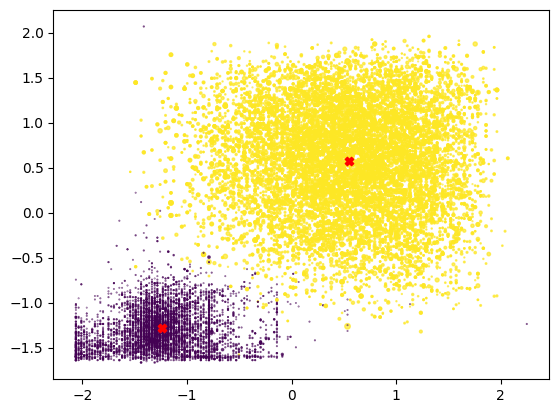

In [15]:
plt.scatter(x[:,2],x[:,5],s=np.pi**(x[:,-2]),c=label,alpha=0.7)
plt.scatter(center[:,2],center[:,5],marker='X',c='red')

In [16]:
c=pd.DataFrame(x.copy())
c['prediction']=kmn.fit_predict(x)
c

,0,1,2,3,4,5,6,7,8,9,10,prediction
0,0.746903,-0.533679,-0.347872,-1.529816,-1.010526,-1.547874,-1.816801,-0.762353,0.532705,-1.103717,-1.938567,1
1,0.249775,-0.451489,-0.789632,-1.535075,-0.001962,-1.612670,-2.126242,-0.878712,0.007517,-0.956764,-2.446108,1
2,-0.993047,1.123827,-2.062940,-1.422006,-0.826423,-1.612670,-2.146206,-1.111431,2.750170,-1.177194,-0.500533,1
3,0.249775,-0.917234,-0.971533,-1.566629,-0.442208,-1.236854,-1.806819,-0.968475,1.291312,-0.393445,-1.177255,1
4,-0.620201,0.671780,-2.010969,-1.466707,-0.930481,-1.599710,-2.176151,-0.918607,1.874855,-1.299654,-0.246763,1
...,...,...,...,...,...,...,...,...,...,...,...,...
20995,-0.040217,0.671780,0.301775,0.983998,1.694987,-0.192344,-0.472233,0.904078,0.824477,-0.319969,0.599139,0
20996,0.166920,-0.451489,0.223818,1.183840,0.398262,-0.868813,-0.242649,1.478394,2.108272,0.292335,-1.346435,0
20997,1.492597,-0.862441,0.639592,1.094437,1.991152,-0.861038,0.444109,1.347075,-1.568050,1.810847,-1.684796,0
20998,-1.324467,0.699177,0.769521,-0.314981,-0.498239,0.652594,0.658721,1.229053,-1.276278,1.272020,1.360451,0


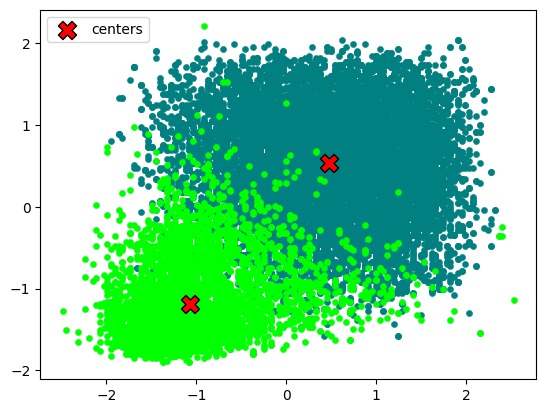

In [17]:
plt.scatter(x=c[c['prediction']==0][0],y=c[c['prediction']==0][1],s=20,edgecolor='teal',c='teal',linewidth=0.3)
plt.scatter(x=c[c['prediction']==1][0],y=c[c['prediction']==1][1],s=20,edgecolor='lime',c='lime',linewidth=0.3)
plt.scatter(center[:,0],center[:,1],marker='X',c='red',edgecolor='black',s=170,label='centers')
plt.legend()
plt.show()

In [19]:
newdata={'fixed_acidity':[11.6], 'volatile_acidity':[0.580], 'citric_acid':[0.66], 'residual_sugar':[2.20],'chlorides':[0.074], 'free_sulfur_dioxide':[10.0], 'total_sulfur_dioxide':[47.0], 'density':[1.00080],'pH':[3.25], 'sulphates':[0.57], 'alcohol':[9.0]}
neaw_data=pd.DataFrame(newdata)
scale=StandardScaler()
neaw_data=scale.fit_transform(neaw_data)
predict=kmn.predict(neaw_data)
print(f'predicted quality:{predict}') #True prediction

predicted quality:[0]


In [ ]:
#MeanShift

In [21]:
data=pd.read_csv(r'D:\jupyter\wine_data.csv')
x=data.iloc[:,:-1]
scale=StandardScaler()
x=scale.fit_transform(x)

In [22]:
bandwidth=estimate_bandwidth(x,n_samples=21000)

In [23]:
ms=MeanShift(bandwidth=bandwidth)
ms.fit(x)
label=ms.labels_
center=ms.cluster_centers_

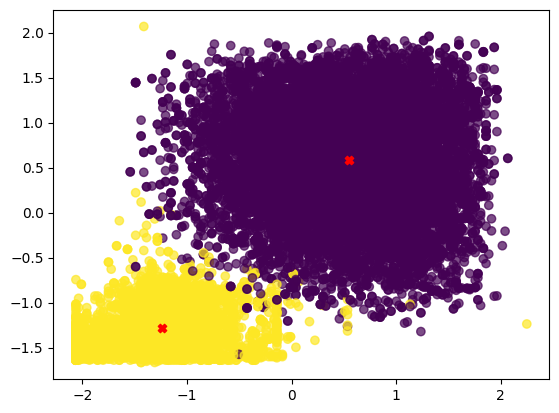

In [24]:
plt.scatter(x[:,2],x[:,5],cmap='viridis',c=label,alpha=0.7,marker='o')
plt.scatter(center[:,2],center[:,5],marker='X',c='red')
plt.show()

In [26]:
newdata={'fixed_acidity':[11.6], 'volatile_acidity':[0.580], 'citric_acid':[0.66], 'residual_sugar':[2.20],'chlorides':[0.074], 'free_sulfur_dioxide':[10.0], 'total_sulfur_dioxide':[47.0], 'density':[1.00080],'pH':[3.25], 'sulphates':[0.57], 'alcohol':[9.0]}
neaw_data=pd.DataFrame(newdata)
scale=StandardScaler()
neaw_data=scale.fit_transform(neaw_data)
predict=ms.predict(neaw_data)
print(f'predicted quality:{predict}') #True prediction

predicted quality:[0]


In [27]:
#DBSCAN

In [29]:
data=pd.read_csv(r'D:\jupyter\wine_data.csv')
x=data.iloc[:,:-1]
scale=StandardScaler()
x=scale.fit_transform(x)

In [30]:
db=DBSCAN(eps=0.5,min_samples=10)
db.fit(x)
y=db.fit_predict(x)

In [31]:
core=np.zeros_like(db.labels_,dtype=bool)
core[db.core_sample_indices_]=True
labels=db.labels_
label_set=set(labels)
print(label_set)

{0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, -1}


In [32]:
n_cluster=len(set(labels))-(1 if -1 in labels else 0)
u_label=set(labels)
print('n_cluster: ',n_cluster)
print('u_label:',u_label)

n_cluster:  14
u_label: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, -1}


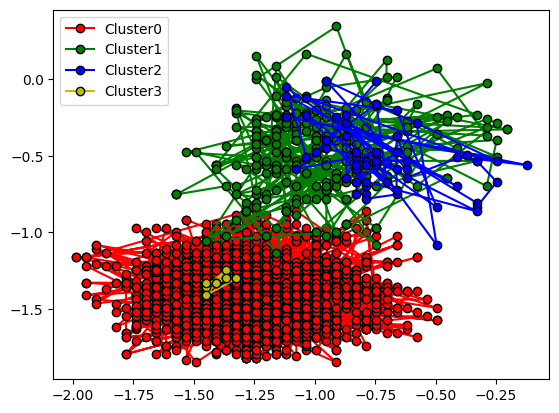

In [33]:
color=['r','g','b','y']
for k,col in zip(u_label,color):
    if k==-1:
        xy=x[labels==k]
        plt.plot(xy[:,0],xy[:,1],marker='o',color='k',markeredgecolor='k',markersize=6,label='Noise')
    else:
        xy=x[labels==k]
        plt.plot(xy[:,0],xy[:,1],marker='o',color=col,markeredgecolor='k',markersize=6,label=f'Cluster{k}')
plt.legend()
plt.show()

In [34]:
#linkage

In [35]:
data=pd.read_csv(r'D:\jupyter\wine_data.csv')

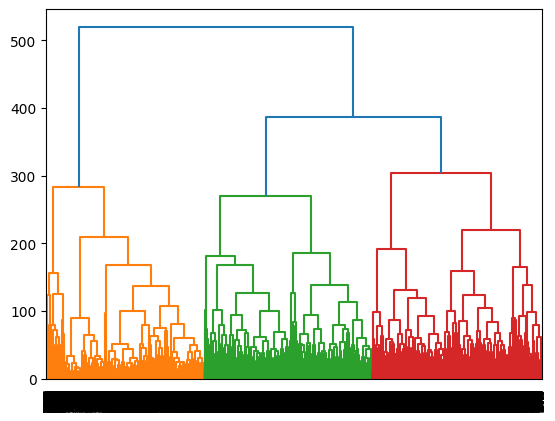

In [38]:
link=linkage(data,method='complete')
dendrogram(link)
plt.show()

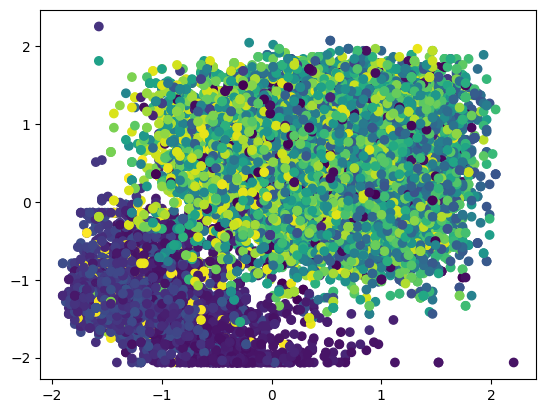

In [39]:
label=fcluster(link,3,criterion='distance')
plt.scatter(x[:,1],x[:,2],c=label)
plt.show()